## Path planning: interpolation + IK branch tracking

In [35]:
import sys
import numpy as np
from scipy.spatial.transform import Rotation, Slerp

sys.path.insert(0, '/Users/axel/axel/code/IKDH/build')
import ikdh

robot = ikdh.load_robot('/Users/axel/axel/code/IKDH/robots/gofa5.yaml')
solver = ikdh.Solver(robot.dh, robot.limits)


def interpolate_poses(pose_a: np.ndarray, pose_b: np.ndarray, n: int) -> list[np.ndarray]:
    """Cartesian interpolation between two 4x4 homogeneous poses.
    Translation: linear. Rotation: SLERP. Returns n poses including A and B.
    """
    t_a, t_b = pose_a[:3, 3], pose_b[:3, 3]
    r_a = Rotation.from_matrix(pose_a[:3, :3])
    r_b = Rotation.from_matrix(pose_b[:3, :3])
    slerp = Slerp([0.0, 1.0], Rotation.concatenate([r_a, r_b]))

    poses = []
    for s in np.linspace(0.0, 1.0, n):
        T = np.eye(4)
        T[:3, :3] = slerp(s).as_matrix()
        T[:3, 3]  = (1.0 - s) * t_a + s * t_b
        poses.append(T)
    return poses


def plan_paths(solver, poses: list[np.ndarray], jump_threshold_deg: float = 30.0):
    """Track all IK branches simultaneously from A to B.

    Uses solve_from_seed() for poses 1..N: each branch warm-starts Newton from
    its previous joint configuration, bypassing the full algebraic solver.
    This is ~100x faster than re-solving all branches from scratch at every pose.

    Returns:
      branches : list of lists, shape (n_branches, n_poses)
                 each entry is np.ndarray (6,) in degrees, or None if the
                 branch died (joint limit / singularity).
    """
    # --- Step 0: full algebraic solve at pose A to seed all branches ---
    solutions = solver.solve(poses[0])
    if not solutions:
        print("[ERROR] No IK solution at pose A")
        return []

    branches = [[q] for q in solutions]

    # --- Extend each branch via warm-start Newton (one seed per branch/pose) ---
    for pose in poses[1:]:
        for branch in branches:
            if branch[-1] is None:
                branch.append(None)
                continue

            result = solver.solve_from_seed(pose, branch[-1])
            if not result:
                branch.append(None)
                continue

            if np.linalg.norm(result[0] - branch[-1]) > jump_threshold_deg:
                branch.append(None)
            else:
                branch.append(result[0])

    return branches


# -- Poses A and B -------------------------------------------------------------
pose_A = ikdh.pose_from_xyzrpw(800.0,  200.0, 300.0,  0.0, 135.0, 0.0)
pose_B = ikdh.pose_from_xyzrpw(800.0, -200.0, 300.0,  0.0, 135.0, 0.0)

N_POINTS = 1000

poses = interpolate_poses(pose_A, pose_B, N_POINTS)

# -- Plan ----------------------------------------------------------------------
branches = plan_paths(solver, poses)

print(f"{len(branches)} branch(es) at start")
for b, branch in enumerate(branches):
    n_valid = sum(q is not None for q in branch)
    died_at = next((i for i, q in enumerate(branch) if q is None), None)
    status  = f"dies at step {died_at}" if died_at is not None else "full path"
    print(f"  Branch {b}: {n_valid}/{N_POINTS} valid — {status}")

8 branch(es) at start
  Branch 0: 500/1000 valid — dies at step 500
  Branch 1: 500/1000 valid — dies at step 500
  Branch 2: 500/1000 valid — dies at step 500
  Branch 3: 500/1000 valid — dies at step 500
  Branch 4: 506/1000 valid — dies at step 506
  Branch 5: 1000/1000 valid — full path
  Branch 6: 500/1000 valid — dies at step 500
  Branch 7: 500/1000 valid — dies at step 500


In [36]:
import math, sys
sys.path.insert(0, '/Users/axel/axel/code/IKDH/tools')
from eval_jacobian import load_jacobian, evaluate_jacobian

_jac_rows = load_jacobian('/Users/axel/axel/code/IKDH/robots/gofa5.yaml')
_lim_lo = robot.limits.lo
_lim_hi = robot.limits.hi

LIMIT_MARGIN = 2.0   # deg
SINGULAR_THR = 1e-4  # |det(J)|

for b, branch in enumerate(branches):
    stop = next((i for i, q in enumerate(branch) if q is None), None)
    if stop is None:
        print(f"Branch {b}: full path")
        continue

    q     = branch[stop - 1]
    q_rad = [math.radians(v) for v in q]

    hits = [f"J{j+1}={q[j]:.1f}°" for j in range(6)
            if q[j] <= _lim_lo[j] + LIMIT_MARGIN or q[j] >= _lim_hi[j] - LIMIT_MARGIN]

    det = abs(np.linalg.det(evaluate_jacobian(_jac_rows, q_rad)))

    if hits:
        cause = f"joint limit ({', '.join(hits)})"
    elif det < SINGULAR_THR:
        cause = f"singularity (|det J| = {det:.2e})"
    else:
        cause = f"unknown (|det J| = {det:.2e})"

    print(f"Branch {b}: stops at step {stop} — {cause}")

Branch 0: stops at step 500 — joint limit (J1=-180.0°, J4=180.0°)
Branch 1: stops at step 500 — joint limit (J1=-180.0°, J6=-180.0°)
Branch 2: stops at step 500 — joint limit (J1=-180.0°, J4=180.0°)
Branch 3: stops at step 500 — joint limit (J1=-180.0°, J6=-180.0°)
Branch 4: stops at step 506 — unknown (|det J| = 7.31e-04)
Branch 5: full path
Branch 6: stops at step 500 — joint limit (J4=180.0°, J6=-180.0°)
Branch 7: stops at step 500 — joint limit (J4=179.9°, J6=-179.9°)


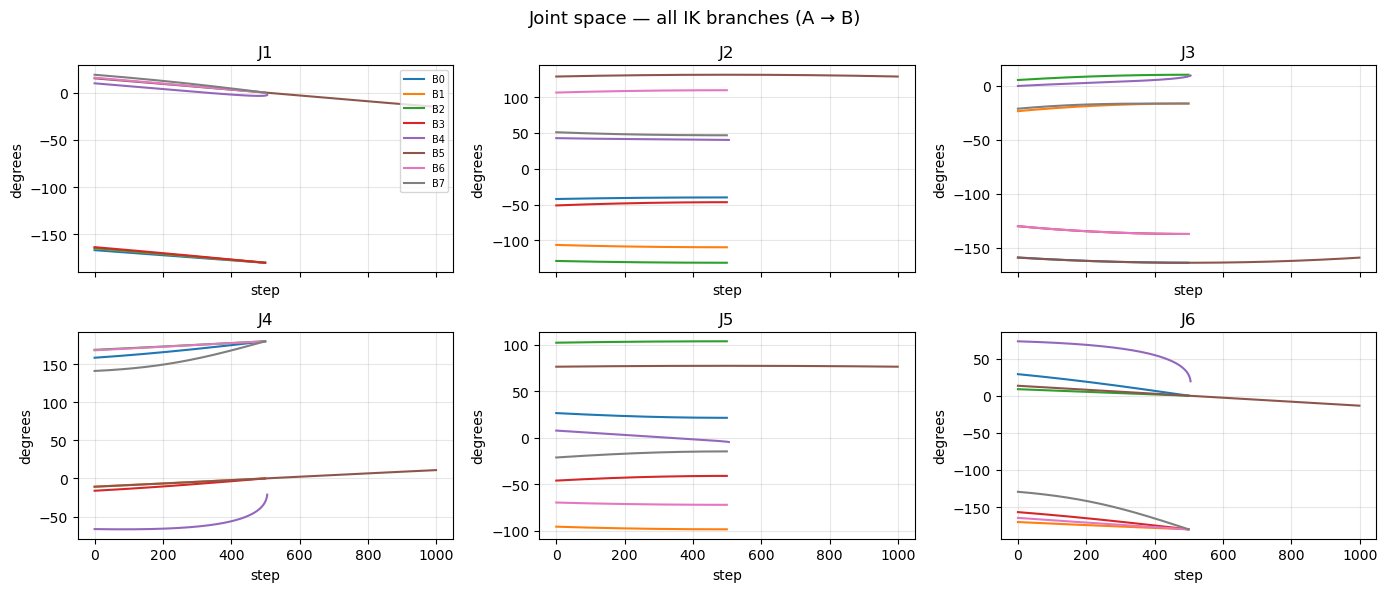

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
axes = axes.flatten()

for b, branch in enumerate(branches):
    # Build masked array so None gaps show as breaks in the line
    data = np.array([q if q is not None else [np.nan]*6 for q in branch])
    for j in range(6):
        axes[j].plot(data[:, j], linewidth=1.5, label=f'B{b}')

for j in range(6):
    axes[j].set_title(f'J{j+1}')
    axes[j].set_ylabel('degrees')
    axes[j].set_xlabel('step')
    axes[j].grid(True, alpha=0.3)

axes[0].legend(fontsize=7, loc='upper right')
plt.suptitle('Joint space — all IK branches (A → B)', fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
import time

BRANCH_IDX = 3    # index of the branch to send
DELAY_S    = 0.001  # seconds between each waypoint

selected = branches[BRANCH_IDX]
valid    = [q for q in selected if q is not None]

try:
    from robodk.robolink import Robolink
    RDK   = Robolink()
    robot = RDK.Item('ABB CRB 15000')
    if not robot.Valid():
        print("[ERROR] Robot not found in RoboDK")
    else:
        if len(valid) < len(selected):
            print(f"[WARN] Branch {BRANCH_IDX} dies at step {len(valid)}")
        for q in valid:
            robot.setJoints(q.tolist())
            time.sleep(DELAY_S)
        print(f"Done — {len(valid)}/{len(selected)} waypoints sent (branch {BRANCH_IDX})")
except ImportError:
    print("robodk not installed — skipping RoboDK streaming.")

[WARN] Branch 3 dies at step 500
Done — 500/1000 waypoints sent (branch 3)
